## **1. Загрузка данных**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv('train.csv')

## **2. Отображение структуры данных**

Количество строк и столбцов

In [4]:
df.shape

(891, 12)

Название всех столбцов

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Типы данных столбцов

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## **3. Анализ пассажиров**

In [7]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Количество пассажиров каждого класса

In [9]:
pass_kolichecnvo = df['Pclass'].value_counts().sort_index()
pass_kolichecnvo

,count
Pclass,
1,216
2,184
3,491


Количество мужчин и женщин

In [10]:
kol_men_women = df['Sex'].value_counts()
kol_men_women

,count
Sex,
male,577
female,314


Возрастные группы пассажиров

In [16]:
bins = [0, 18, 50, 100]
labels = ['0-18', '19-50', '50+']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
df['Age_group']

,Age_group
0,19-50
1,19-50
2,19-50
3,19-50
4,19-50
...,...
886,19-50
887,19-50
888,NaN
889,19-50


Средний возраст пассажиров

In [23]:
mean = df['Age'].mean()
mean

np.float64(29.69911764705882)

Медианный возраст

In [24]:
median = df['Age'].median()
median

28.0

Средняя стоимость билета

In [26]:
mean_bilet = df['Fare'].mean()
mean_bilet

np.float64(32.204207968574636)

## **4. Сравнение пассажиров разных классов**

Сравнение средней стоимости билета для 1, 2, и 3 классов

In [29]:
mean_bilet_klass = df.groupby('Pclass')['Fare'].mean().round(2) #round(2) округляет данные до 2х знаков после запятой
mean_bilet_klass

,Fare
Pclass,
1,84.15
2,20.66
3,13.68


Сравнение среднего возраста пассажиров разных классов

In [30]:
mean_age = df.groupby('Pclass')['Age'].mean().round(2)
mean_age

,Age
Pclass,
1,38.23
2,29.88
3,25.14


Сравнение кол-ва мужчин и женщин в каждом классе

In [32]:
kol_pol = df.groupby(['Pclass', 'Sex']).size()
kol_pol

Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      347
dtype: int64

Класс с большим количеством пассажиров

In [38]:
most_common_class = df['Pclass'].mode()[0]
most_common_class #в третьем классе

np.int64(3)

In [39]:
#для пояснения почему именно в 3 классе
df['Pclass'].value_counts().sort_index()

,count
Pclass,
1,216
2,184
3,491


Небольшой вывод о различиях между классами

*   1 класс: средние возраста и стоимости билеты самые большие.
*   2 класс: промежуточное положение между параметрами 1 и 3 класса.
*   3 класс: самый мнгогочисленный класс, молодой и с дешевыми билетами.

Самый дорогой билет (с определением класса, возраста, пола и факта выживания)

In [41]:
row = df.loc[df['Fare'].idxmax()]

print(f"Билет: {row['Fare']}, класс: {row['Pclass']}, "
      f"возраст: {row['Age']}, пол: {row['Sex']}, выжил: {row['Survived']}")

Билет: 512.3292, класс: 1, возраст: 35.0, пол: female, выжил: 1


## **5. Анализ выживаемости**

Общее количество выживших и погибших

In [43]:
Kol_analiz = df['Survived'].value_counts().rename({0: 'Погибшие', 1: 'Выжившие'})
Kol_analiz

,count
Survived,
Погибшие,549
Выжившие,342


Выживаемость мужчин и женщин (в процентах)

In [44]:
Kol_analiz_pol = (df.groupby('Sex')['Survived'].mean() * 100).round(1)
Kol_analiz_pol

,Survived
Sex,
female,74.2
male,18.9


Выживаемость по полу и классу (в процентах)

In [45]:
Kol_analiz_pol_klass = (df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100).round(1)
Kol_analiz_pol_klass

Pclass  Sex   
1       female    96.8
        male      36.9
2       female    92.1
        male      15.7
3       female    50.0
        male      13.5
Name: Survived, dtype: float64

Группа с наибольшей долей выживших

In [51]:
best_group = Kol_analiz_pol.idxmax()
best_group #лучшая группа выживаемости по полу

'female'

In [52]:
best_rezultat = Kol_analiz_pol[best_group]
best_rezultat #к-во цифр выживаемости

np.float64(74.2)

## **6. Визуализация**

Количество пассажиров по классам

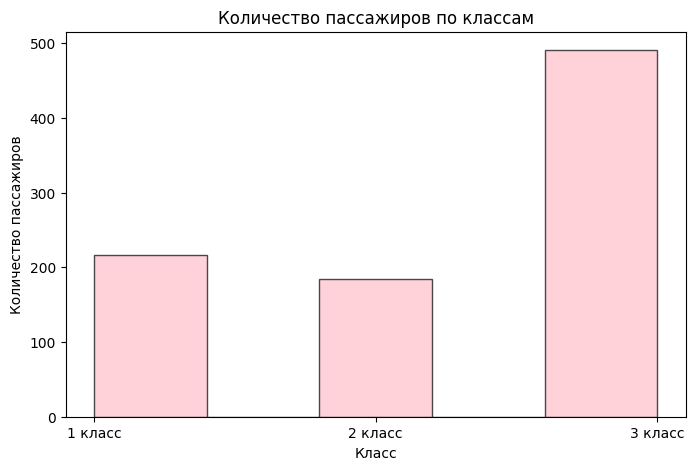

In [68]:
plt.figure(figsize=(8, 5))
plt.hist(df['Pclass'], bins=5, edgecolor='black', alpha=0.7, color='pink')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.xticks([1, 2, 3], ['1 класс', '2 класс', '3 класс'])  # подписи осей
plt.show()

Выживаемость по полу

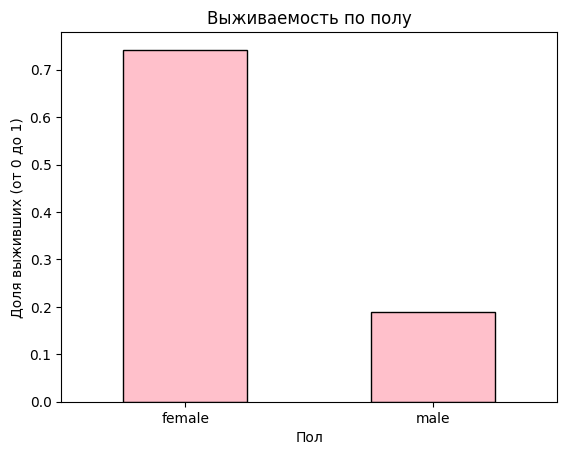

In [67]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color='pink', edgecolor='black')
#groupby для доли выживших процентно, например: 0.74 = 74%
plt.title('Выживаемость по полу')
plt.ylabel('Доля выживших (от 0 до 1)')
plt.xlabel('Пол')
plt.xticks(rotation=0)  # чтобы подписи были горизонтально
plt.show()

## **Самостоятельный вопрос:**

*Кто чаще выживал — пассажиры 1‑го класса или 3‑го?*

In [70]:
survival_by_class = (df.groupby('Pclass')['Survived'].mean() * 100).round(1)
survival_by_class

,Survived
Pclass,
1,63.0
2,47.3
3,24.2


*Сколько детей (до 12 лет) выжило в каждом классе?*

In [71]:
kids = df[(df['Age'] < 12) & (df['Age'].notna())]
kids.groupby('Pclass')['Survived'].sum()

,Survived
Pclass,
1,3
2,17
3,19
